# Chapter 06: Linear Algebra

**Source orientation:** printed pages 107-126; physical PDF pages 124-143. I used the source pages to orient the chapter sequence: determinants, matrix arithmetic, matrix operations, inverses, small linear systems, eigenvectors, diagonalization, and singular value decomposition. The prose, code, examples, and visuals in this notebook are original and standalone.

## Chapter Goal

Make the algebra used by graphics transforms inspectable. A determinant is a signed area or volume measurement; a matrix product is composition; an inverse undoes a map or solves a small system; eigenvectors are directions that survive a transform; and the SVD turns a general real matrix into input directions, axis scales, and output directions.

Tiny examples matter because graphics failures usually appear first as tiny invariant failures: the transform order is reversed, a determinant has the wrong sign, an intended rotation is not orthogonal, a system is almost singular, or a normal was transformed like a point. The notebook builds small objects whose behavior can be seen and audited.

## Computational Translation Guide

| Book concept | Computational translation | Main check |
| --- | --- | --- |
| 2D determinant | signed area of a parallelogram | shoelace area agrees with `np.linalg.det` |
| 3D determinant | signed volume of a parallelepiped | triple product agrees with determinant |
| Matrix columns | images of basis vectors under a linear map | transformed grid and unit circle match `A @ x` |
| Matrix product | composition, row-column dot products, and column combinations | hand-computed entries match `A @ B` |
| Inverse | map that recovers the input and solves `A x = b` | `A @ inv(A)` is identity and residual is small |
| Cramer's rule | determinant ratios for small square systems | determinant-ratio solution matches `solve` |
| Eigenvectors | directions whose span is preserved | `A v = lambda v` residuals vanish |
| Symmetric diagonalization | orthogonal eigenbasis plus diagonal stretch | `A = Q D Q.T` reconstruction residual is small |
| SVD | input rotation, axis scale, output rotation | `sigma_i^2` are eigenvalues of `A.T @ A` |
| Normal transform | inverse-transpose action on perpendicularity constraints | transformed normal is perpendicular to transformed tangents |

## Visual Storyboard

| Order | Concept | Representation | Library | Artifact | Inspection target | Validation |
| ---: | --- | --- | --- | --- | --- | --- |
| 1 | Dependency route | directed concept map | NetworkX + Matplotlib | `concept-dependency-map.png` | which ideas depend on determinant geometry | graph counts |
| 2 | Determinants | signed area, shear invariance, 3D volume | Matplotlib + SymPy | `determinant-area-volume.png` | sign, area preservation, volume | determinant identities |
| 3 | Linear maps | interactive transformed grid, circle, basis | Plotly | `graphics-linear-map-lab.html` | columns are moved basis vectors | determinant and basis checks |
| 4 | Matrix products | row dots, column combinations, order | Matplotlib | `matrix-product-interpretations.png` | why `A @ B` and `B @ A` differ | row/column and product checks |
| 5 | Inverse/systems | Cramer geometry and residual bars | Matplotlib + CSV | `inverse-linear-system-cramer.png` | determinant denominator controls uniqueness | solve and inverse checks |
| 6 | Eigen geometry | symmetric transform and characteristic roots | Matplotlib + SymPy | `eigen-diagonalization-geometry.png` | invariant directions and eigenbasis | diagonalization checks |
| 7 | SVD geometry | staged rotation-scale-rotation | Matplotlib + NumPy | `determinant-svd-geometry.png` | singular vectors explain nonsymmetric stretch | SVD/eigen checks |
| 8 | Graphics lab | transformed tangent patch and normals | Matplotlib 3D | `graphics-normal-transform-lab.png` | normals are constraints, not ordinary vectors | inverse-transpose check |

Matplotlib is used for durable annotated geometric diagrams, Plotly for the inspectable linear-map artifact, SymPy for exact determinant and characteristic-polynomial identities, and NumPy for the numerical linear algebra that graphics code typically calls.

In [1]:
CHAPTER = 6
TITLE = "Linear Algebra"
UNIT = "chapter-06"
PRINTED_PAGES = "107-126"
PDF_PAGES = "124-143"
SOURCE_SPAN = {"printed_pages": PRINTED_PAGES, "pdf_pages": PDF_PAGES, "source_note": "Read with pdftotext -f 124 -l 143 before authoring."}

from pathlib import Path
import sys
BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the FCG book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
for kind in ["figures", "html", "checks", "tables"]:
    (ARTIFACT_ROOT / kind).mkdir(parents=True, exist_ok=True)
ARTIFACT_ROOT.relative_to(BOOK_ROOT)

WindowsPath('artifacts/chapter-06')

In [2]:
from itertools import product
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

from utils.artifacts import assert_artifacts, display_artifact, save_json, save_matplotlib, save_plotly_html, save_table_csv
from utils.notebook_checks import assert_nonblank_image

PALETTE = {"ink":"#1f2937", "paper":"#fbfaf6", "grid":"#d7dce2", "blue":"#2563eb", "teal":"#0f766e", "gold":"#b7791f", "red":"#dc2626", "violet":"#6d28d9", "gray":"#64748b", "green":"#15803d"}
artifact_paths, image_paths, html_paths, check_paths, table_paths = [], [], [], [], []
numeric_checks = {}

def remember(path, kind):
    path = Path(path)
    artifact_paths.append(path)
    {"image": image_paths, "html": html_paths, "check": check_paths, "table": table_paths}[kind].append(path)
    return path

def rel_book(path):
    p = Path(path)
    if not p.is_absolute() and p.parts and p.parts[0] == "artifacts":
        return p.as_posix()
    try:
        return p.resolve().relative_to(BOOK_ROOT).as_posix()
    except ValueError:
        return p.as_posix()

def close(fig):
    plt.close(fig)

def setup_2d(ax, title, xlim=(-2.2, 2.2), ylim=(-2.2, 2.2)):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.axhline(0, color=PALETTE["grid"], linewidth=0.8); ax.axvline(0, color=PALETTE["grid"], linewidth=0.8)
    ax.grid(True, color=PALETTE["grid"], linewidth=0.5, alpha=0.65)
    ax.set_title(title, fontsize=10)

def arrow2(ax, start, end, color, label=None, linewidth=2.0, mutation_scale=12):
    start = np.asarray(start, dtype=float); end = np.asarray(end, dtype=float)
    patch = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=mutation_scale, linewidth=linewidth, color=color)
    ax.add_patch(patch)
    if label:
        mid = start + 0.56 * (end - start)
        ax.text(mid[0], mid[1], label, color=color, fontsize=9, weight="bold")
    return patch

def polygon_area(points):
    pts = np.asarray(points, dtype=float); x = pts[:, 0]; y = pts[:, 1]
    return 0.5 * float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

def normalize(v):
    v = np.asarray(v, dtype=float); n = np.linalg.norm(v)
    if n == 0: raise ValueError("zero vector")
    return v / n

def circle_points(n=240):
    t = np.linspace(0, 2 * np.pi, n)
    return np.column_stack([np.cos(t), np.sin(t)])

def max_abs(M):
    return float(np.max(np.abs(np.asarray(M, dtype=float))))

np.set_printoptions(precision=4, suppress=True)

## Dependency Route

The chapter is a chain, not a bag of formulas. Determinants measure oriented size; that measurement explains singularity, inverse existence, and Cramer's rule. Matrix multiplication then becomes both a computational rule and a geometric composition rule. Eigen decomposition and SVD reuse the same matrix machinery but expose privileged directions: eigenvectors for symmetric maps and singular vectors for general maps.

The dependency map is a checkable object. It records which concepts feed later ones and gives the final sanity cell a small graph invariant to verify.

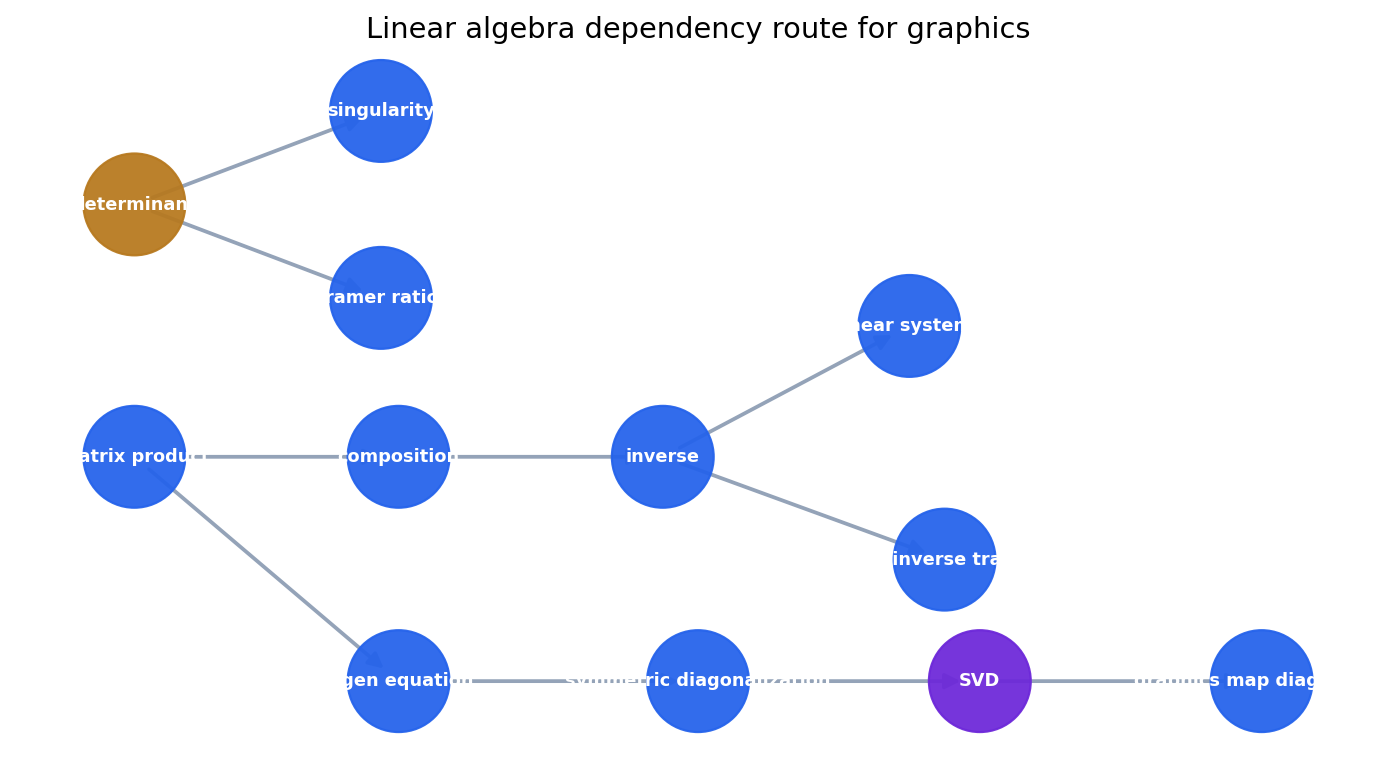

In [3]:
visual_storyboard = [
    {"order": 1, "concept": "dependency route", "artifact": "figures/concept-dependency-map.png"},
    {"order": 2, "concept": "determinant area volume", "artifact": "figures/determinant-area-volume.png"},
    {"order": 3, "concept": "graphics linear map", "artifact": "html/graphics-linear-map-lab.html"},
    {"order": 4, "concept": "matrix product interpretations", "artifact": "figures/matrix-product-interpretations.png"},
    {"order": 5, "concept": "inverse linear system Cramer", "artifact": "figures/inverse-linear-system-cramer.png"},
    {"order": 6, "concept": "eigen diagonalization geometry", "artifact": "figures/eigen-diagonalization-geometry.png"},
    {"order": 7, "concept": "SVD eigen geometry", "artifact": "figures/determinant-svd-geometry.png"},
    {"order": 8, "concept": "graphics normal transform lab", "artifact": "figures/graphics-normal-transform-lab.png"},
]
route_edges = [
    ("determinant", "singularity"), ("determinant", "Cramer ratios"),
    ("matrix product", "composition"), ("composition", "inverse"),
    ("inverse", "linear systems"), ("matrix product", "eigen equation"),
    ("eigen equation", "symmetric diagonalization"), ("symmetric diagonalization", "SVD"),
    ("SVD", "graphics map diagnostics"), ("inverse", "normal inverse transpose"),
]
G = nx.DiGraph(route_edges)
pos = {"determinant": (0, 1), "singularity": (1.4, 1.5), "Cramer ratios": (1.4, .5), "matrix product": (0, -.35), "composition": (1.5, -.35), "inverse": (3, -.35), "linear systems": (4.4, .35), "normal inverse transpose": (4.6, -.9), "eigen equation": (1.5, -1.55), "symmetric diagonalization": (3.2, -1.55), "SVD": (4.8, -1.55), "graphics map diagnostics": (6.4, -1.55)}
fig, ax = plt.subplots(figsize=(11, 5.6)); ax.set_facecolor(PALETTE["paper"])
nx.draw_networkx_edges(G, pos, ax=ax, arrowstyle="-|>", arrowsize=14, edge_color="#94a3b8", width=1.7)
node_colors = [PALETTE["gold"] if n == "determinant" else PALETTE["violet"] if n == "SVD" else PALETTE["blue"] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=2100, alpha=.94)
nx.draw_networkx_labels(G, pos, ax=ax, font_color="white", font_size=8, font_weight="bold")
ax.set_title("Linear algebra dependency route for graphics", fontsize=13); ax.axis("off")
concept_map_path = remember(save_matplotlib(fig, UNIT, "concept-dependency-map.png"), "image"); close(fig)
storyboard_path = remember(save_json({"chapter": CHAPTER, "title": TITLE, "items": visual_storyboard}, UNIT, "visual-storyboard.json"), "check")
numeric_checks["storyboard"] = {"item_count": len(visual_storyboard), "node_count": G.number_of_nodes(), "edge_count": G.number_of_edges()}
display_artifact(concept_map_path, width=900); display_artifact(storyboard_path)

## Determinants: Signed Size Before Formula

A determinant measures oriented size. In 2D the size is area; in 3D it is volume. The sign carries orientation, so swapping two vectors reverses the sign. That is why determinant code is useful in graphics before we ever solve equations: it tests triangle winding, face orientation, coordinate-frame handedness, and whether a transform flips the object.

The figure shows three facts together. The left panel compares vector orderings. The middle panel shears a parallelogram without changing area. The right panel builds a 3D parallelepiped and records the triple product. The symbolic check is intentionally small and exact so sign errors cannot hide in decimals.

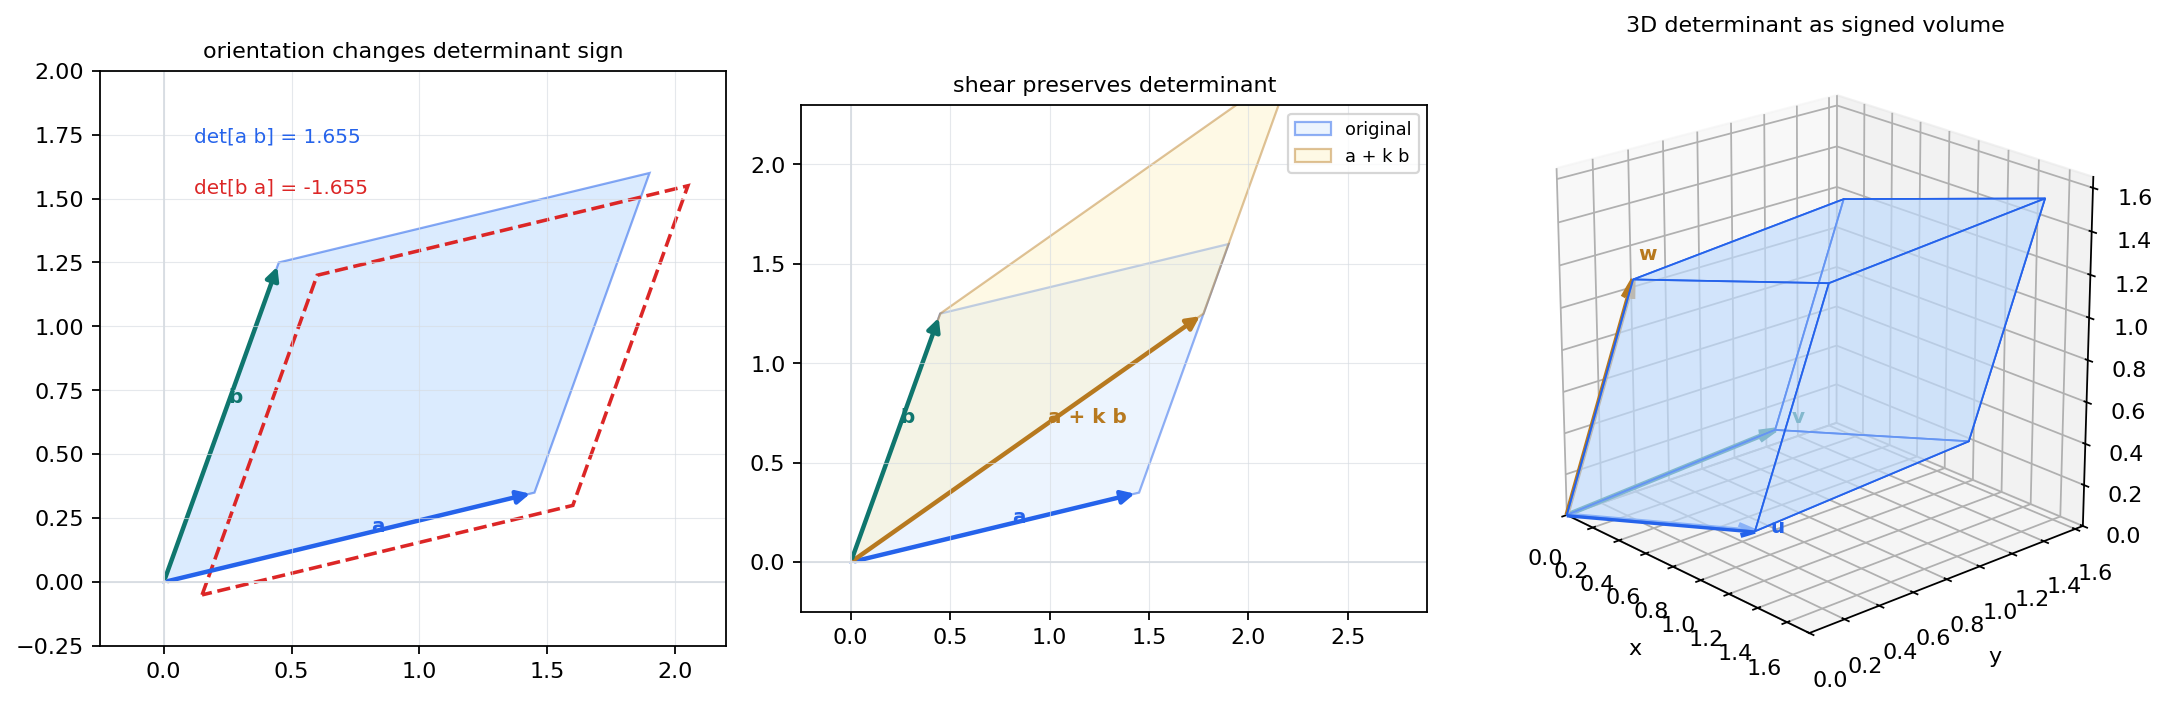

{'det_ab': 1.6549999999999998,
 'det_ba': -1.6549999999999998,
 'shoelace_area': 1.6550000000000002,
 'sheared_det': 1.655,
 'shear_area_error': 2.220446049250313e-16,
 'triple_product_volume': 1.256625,
 'det3_volume': 1.2566250000000003,
 'triple_product_error': 2.220446049250313e-16,
 'symbolic_swap_identity': '0'}

In [4]:
a = np.array([1.45, 0.35]); b = np.array([0.45, 1.25]); k = 0.72
sheared_a = a + k * b
u = np.array([1.2, 0.15, 0.25]); v = np.array([0.25, 1.05, 0.2]); w = np.array([0.15, 0.3, 1.1])
fig = plt.figure(figsize=(13.5, 4.4))
ax1 = fig.add_subplot(1, 3, 1); setup_2d(ax1, "orientation changes determinant sign", xlim=(-.25, 2.2), ylim=(-.25, 2.0))
poly_pos = np.array([[0, 0], a, a + b, b]); poly_neg = np.array([[0, 0], b, a + b, a])
ax1.add_patch(Polygon(poly_pos, closed=True, facecolor="#bfdbfe", edgecolor=PALETTE["blue"], alpha=.55))
ax1.add_patch(Polygon(poly_neg + np.array([.15, -.05]), closed=True, facecolor="none", edgecolor=PALETTE["red"], linestyle="--", linewidth=1.6))
arrow2(ax1, [0, 0], a, PALETTE["blue"], "a"); arrow2(ax1, [0, 0], b, PALETTE["teal"], "b")
ax1.text(.12, 1.72, f"det[a b] = {np.linalg.det(np.column_stack([a, b])):.3f}", color=PALETTE["blue"], fontsize=9)
ax1.text(.12, 1.52, f"det[b a] = {np.linalg.det(np.column_stack([b, a])):.3f}", color=PALETTE["red"], fontsize=9)
ax2 = fig.add_subplot(1, 3, 2); setup_2d(ax2, "shear preserves determinant", xlim=(-.25, 2.9), ylim=(-.25, 2.3))
poly_shear = np.array([[0, 0], sheared_a, sheared_a + b, b])
ax2.add_patch(Polygon(poly_pos, closed=True, facecolor="#dbeafe", edgecolor=PALETTE["blue"], alpha=.5, label="original"))
ax2.add_patch(Polygon(poly_shear, closed=True, facecolor="#fef3c7", edgecolor=PALETTE["gold"], alpha=.45, label="a + k b"))
arrow2(ax2, [0, 0], a, PALETTE["blue"], "a"); arrow2(ax2, [0, 0], sheared_a, PALETTE["gold"], "a + k b"); arrow2(ax2, [0, 0], b, PALETTE["teal"], "b")
ax2.legend(loc="upper right", fontsize=8)
ax3 = fig.add_subplot(1, 3, 3, projection="3d")
verts = np.array([[0,0,0], u, v, w, u+v, u+w, v+w, u+v+w])
faces = [[verts[i] for i in face] for face in [[0,1,4,2], [0,1,5,3], [0,2,6,3], [7,5,1,4], [7,6,2,4], [7,5,3,6]]]
ax3.add_collection3d(Poly3DCollection(faces, facecolor="#bfdbfe", edgecolor=PALETTE["blue"], linewidth=.8, alpha=.42))
for vec, color, label in [(u, PALETTE["blue"], "u"), (v, PALETTE["teal"], "v"), (w, PALETTE["gold"], "w")]:
    ax3.quiver(0, 0, 0, *vec, color=color, linewidth=2.2, arrow_length_ratio=.08); ax3.text(*(vec * 1.08), label, color=color, fontsize=9, weight="bold")
ax3.set_title("3D determinant as signed volume", fontsize=10); ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
ax3.set_xlim(0, 1.75); ax3.set_ylim(0, 1.65); ax3.set_zlim(0, 1.65); ax3.view_init(elev=21, azim=-42); ax3.set_box_aspect((1,1,1))
fig.tight_layout(); determinant_path = remember(save_matplotlib(fig, UNIT, "determinant-area-volume.png"), "image"); close(fig)

x1, y1, x2, y2 = sp.symbols("x1 y1 x2 y2")
symbolic_det2 = sp.Matrix([[x1, x2], [y1, y2]]).det(); symbolic_swap = sp.Matrix([[x2, x1], [y2, y1]]).det()
det2 = float(np.linalg.det(np.column_stack([a, b]))); det2_swapped = float(np.linalg.det(np.column_stack([b, a])))
det2_sheared = float(np.linalg.det(np.column_stack([sheared_a, b]))); shoelace = polygon_area(poly_pos)
triple = float(np.dot(np.cross(u, v), w)); det3 = float(np.linalg.det(np.column_stack([u, v, w])))
determinant_checks = {"det_ab": det2, "det_ba": det2_swapped, "shoelace_area": shoelace, "sheared_det": det2_sheared, "shear_area_error": abs(det2_sheared - det2), "triple_product_volume": triple, "det3_volume": det3, "triple_product_error": abs(triple - det3), "symbolic_swap_identity": str(sp.simplify(symbolic_swap + symbolic_det2))}
assert abs(det2 - shoelace) < 1e-12 and abs(det2 + det2_swapped) < 1e-12
assert determinant_checks["shear_area_error"] < 1e-12 and determinant_checks["triple_product_error"] < 1e-12
assert determinant_checks["symbolic_swap_identity"] == "0"
numeric_checks["determinants"] = determinant_checks
display_artifact(determinant_path, width=940); determinant_checks

## Matrices: Linear Maps and Products

A square matrix can be read by its columns: the first column is where the first basis vector goes, the second column is where the second basis vector goes, and so on. This view is more useful in graphics than treating the matrix as only a rectangular array, because transformations are composed constantly.

Matrix multiplication has several equivalent readings. Entry `C[i, j]` is a dot product between row `i` of the left matrix and column `j` of the right matrix. The product `A @ x` is also a linear combination of the columns of `A`, weighted by the entries of `x`. Finally, `A @ B` is a composition: apply `B`, then apply `A`, under column-vector convention. The order matters.

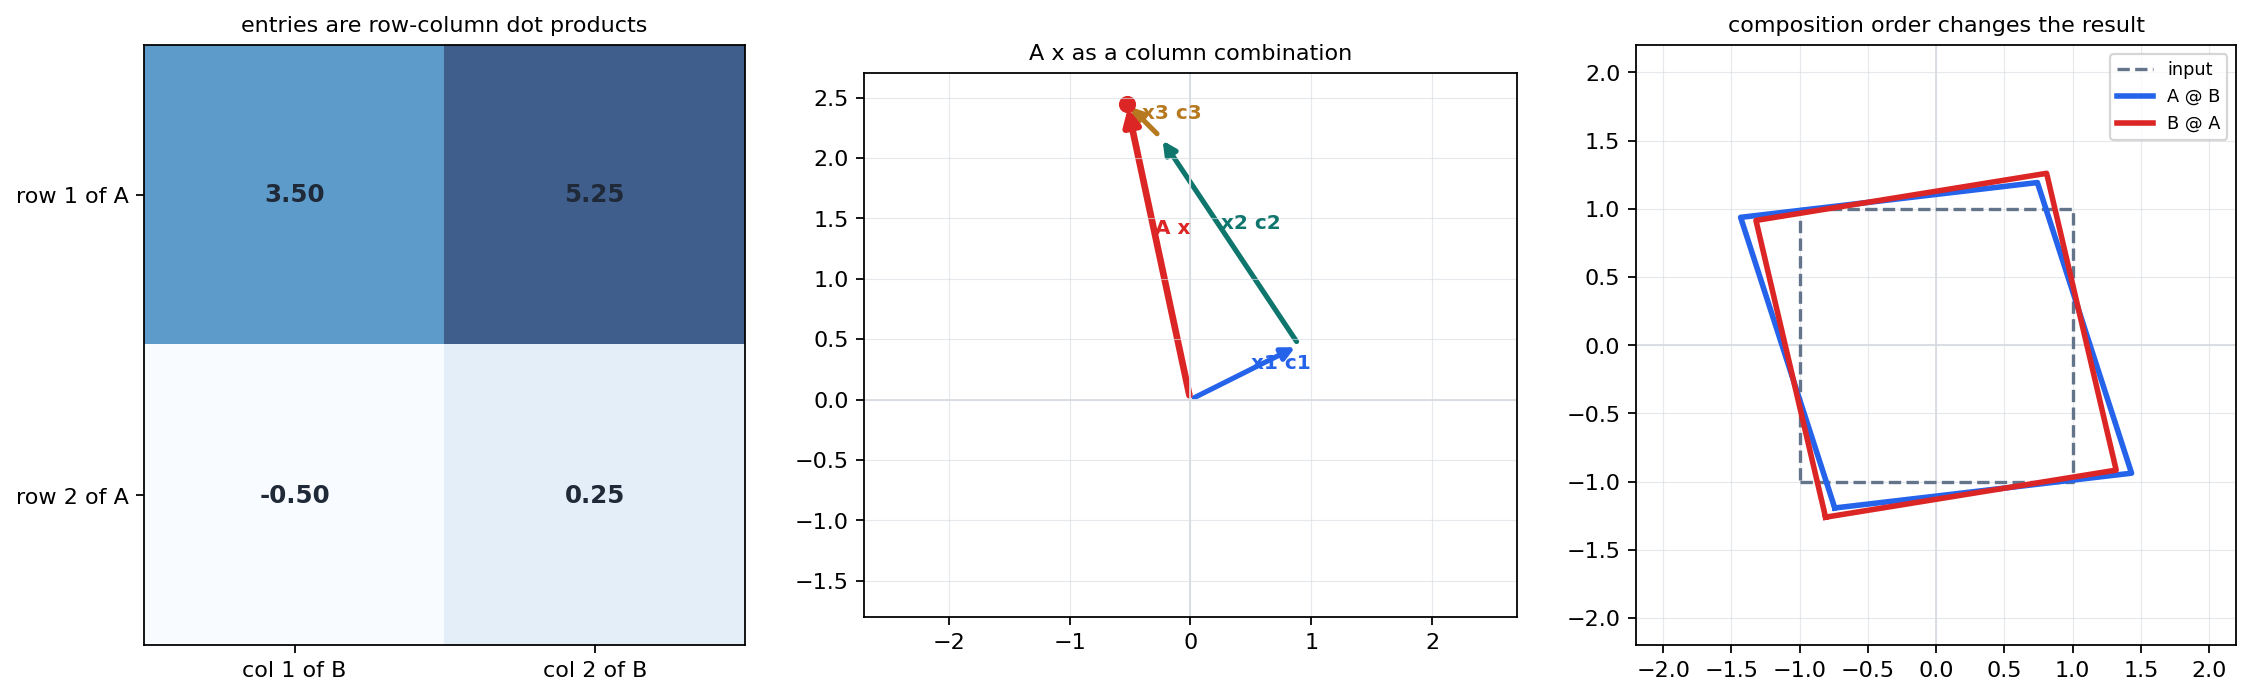

{'linear_map_determinant': 1.1699999999999997,
 'basis_image_e1_error': 0.0,
 'basis_image_e2_error': 0.0,
 'row_dot_error': 0.0,
 'column_combo_error': 0.0,
 'noncommuting_norm': 0.10553435459602717,
 'det_product_error': 2.220446049250313e-16,
 'transpose_product_error': 0.0}

In [5]:
A_map = np.array([[1.15, -0.55], [0.35, 0.85]]); B_map = np.array([[0.85, 0.25], [-0.2, 1.15]])
unit_circle = circle_points(260); unit_square = np.array([[-1,-1],[1,-1],[1,1],[-1,1],[-1,-1]], dtype=float)
figp = go.Figure()
for value in np.linspace(-1.5, 1.5, 7):
    for segment in [np.array([[value, -1.5], [value, 1.5]]), np.array([[-1.5, value], [1.5, value]])]:
        moved = segment @ A_map.T
        figp.add_trace(go.Scatter(x=segment[:,0], y=segment[:,1], mode="lines", line=dict(color="rgba(148,163,184,0.35)", width=1), hoverinfo="skip", showlegend=False))
        figp.add_trace(go.Scatter(x=moved[:,0], y=moved[:,1], mode="lines", line=dict(color="rgba(37,99,235,0.55)", width=1.6), hoverinfo="skip", showlegend=False))
figp.add_trace(go.Scatter(x=unit_circle[:,0], y=unit_circle[:,1], mode="lines", name="unit circle", line=dict(color="#64748b", width=2)))
ellipse = unit_circle @ A_map.T
figp.add_trace(go.Scatter(x=ellipse[:,0], y=ellipse[:,1], mode="lines", name="A times unit circle", line=dict(color="#2563eb", width=3)))
for label, vec, color in [("A e1", A_map[:,0], "#0f766e"), ("A e2", A_map[:,1], "#b7791f")]:
    figp.add_trace(go.Scatter(x=[0, vec[0]], y=[0, vec[1]], mode="lines+markers+text", text=["", label], textposition="top center", line=dict(color=color, width=4), marker=dict(size=6), name=label))
figp.update_layout(title=f"Linear map columns and area scale det(A) = {np.linalg.det(A_map):.3f}", xaxis=dict(scaleanchor="y", scaleratio=1, range=[-2.4,2.4], zeroline=True), yaxis=dict(range=[-2.2,2.2], zeroline=True), width=780, height=620, template="plotly_white", legend=dict(orientation="h", y=1.02))
linear_map_path = remember(save_plotly_html(figp, UNIT, "graphics-linear-map-lab.html", include_plotlyjs="cdn"), "html")

A = np.array([[2.0, -1.0, 0.5], [1.0, 1.5, -0.5]]); B = np.array([[1.0, 2.0], [0.0, -1.0], [3.0, 0.5]])
C = A @ B; x = np.array([0.45, 1.15, -0.55]); y = A @ x
col_combo = x[0] * A[:,0] + x[1] * A[:,1] + x[2] * A[:,2]
square_ab = unit_square @ (A_map @ B_map).T; square_ba = unit_square @ (B_map @ A_map).T
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
axes[0].imshow(C, cmap="Blues", alpha=.78)
for i, j in product(range(C.shape[0]), range(C.shape[1])):
    axes[0].text(j, i, f"{np.dot(A[i,:], B[:,j]):.2f}", ha="center", va="center", fontsize=11, color=PALETTE["ink"], weight="bold")
axes[0].set_xticks(range(C.shape[1]), labels=["col 1 of B", "col 2 of B"]); axes[0].set_yticks(range(C.shape[0]), labels=["row 1 of A", "row 2 of A"])
axes[0].set_title("entries are row-column dot products", fontsize=10)
setup_2d(axes[1], "A x as a column combination", xlim=(-2.7,2.7), ylim=(-1.8,2.7))
running = np.zeros(2)
for idx, (weight, column, color) in enumerate(zip(x, A.T, [PALETTE["blue"], PALETTE["teal"], PALETTE["gold"]]), start=1):
    step = weight * column; arrow2(axes[1], running, running + step, color, f"x{idx} c{idx}", linewidth=2.3); running = running + step
arrow2(axes[1], [0,0], y, PALETTE["red"], "A x", linewidth=3.0, mutation_scale=15); axes[1].scatter([y[0]], [y[1]], color=PALETTE["red"], s=45)
setup_2d(axes[2], "composition order changes the result", xlim=(-2.2,2.2), ylim=(-2.2,2.2))
axes[2].plot(unit_square[:,0], unit_square[:,1], color=PALETTE["gray"], linestyle="--", label="input")
axes[2].plot(square_ab[:,0], square_ab[:,1], color=PALETTE["blue"], linewidth=2.5, label="A @ B")
axes[2].plot(square_ba[:,0], square_ba[:,1], color=PALETTE["red"], linewidth=2.5, label="B @ A"); axes[2].legend(loc="upper right", fontsize=8)
fig.tight_layout(); product_path = remember(save_matplotlib(fig, UNIT, "matrix-product-interpretations.png"), "image"); close(fig)
row_dot_error = max_abs(C - np.array([[np.dot(A[i,:], B[:,j]) for j in range(B.shape[1])] for i in range(A.shape[0])]))
column_combo_error = float(np.linalg.norm(y - col_combo)); noncommuting_norm = float(np.linalg.norm(A_map @ B_map - B_map @ A_map))
det_product_error = float(abs(np.linalg.det(A_map @ B_map) - np.linalg.det(A_map) * np.linalg.det(B_map)))
transpose_product_error = max_abs((A_map @ B_map).T - B_map.T @ A_map.T)
matrix_checks = {"linear_map_determinant": float(np.linalg.det(A_map)), "basis_image_e1_error": float(np.linalg.norm(A_map @ np.array([1.0,0.0]) - A_map[:,0])), "basis_image_e2_error": float(np.linalg.norm(A_map @ np.array([0.0,1.0]) - A_map[:,1])), "row_dot_error": row_dot_error, "column_combo_error": column_combo_error, "noncommuting_norm": noncommuting_norm, "det_product_error": det_product_error, "transpose_product_error": transpose_product_error}
assert row_dot_error < 1e-12 and column_combo_error < 1e-12 and det_product_error < 1e-12 and transpose_product_error < 1e-12
assert matrix_checks["basis_image_e1_error"] < 1e-12 and matrix_checks["basis_image_e2_error"] < 1e-12 and noncommuting_norm > .05
numeric_checks["matrices"] = matrix_checks
display_artifact(linear_map_path, width="100%", height=560); display_artifact(product_path, width=980); matrix_checks

## Inverses and Linear Systems

An inverse exists when a matrix does not collapse area or volume to zero. In a graphics transform, this means the map can be undone. In a linear system, it means there is a unique point satisfying the constraints. For small 2-by-2 or 3-by-3 systems, determinant formulas are compact enough to inspect directly, even though production numerical code usually uses more stable factorizations.

Cramer's rule keeps the geometry visible. Replacing one column of `A` by the target vector `b` asks how much oriented size is needed in that coordinate direction. Dividing by `det(A)` converts that size into a coordinate. If the denominator is zero or nearly zero, the inverse-based answer is fragile or impossible.

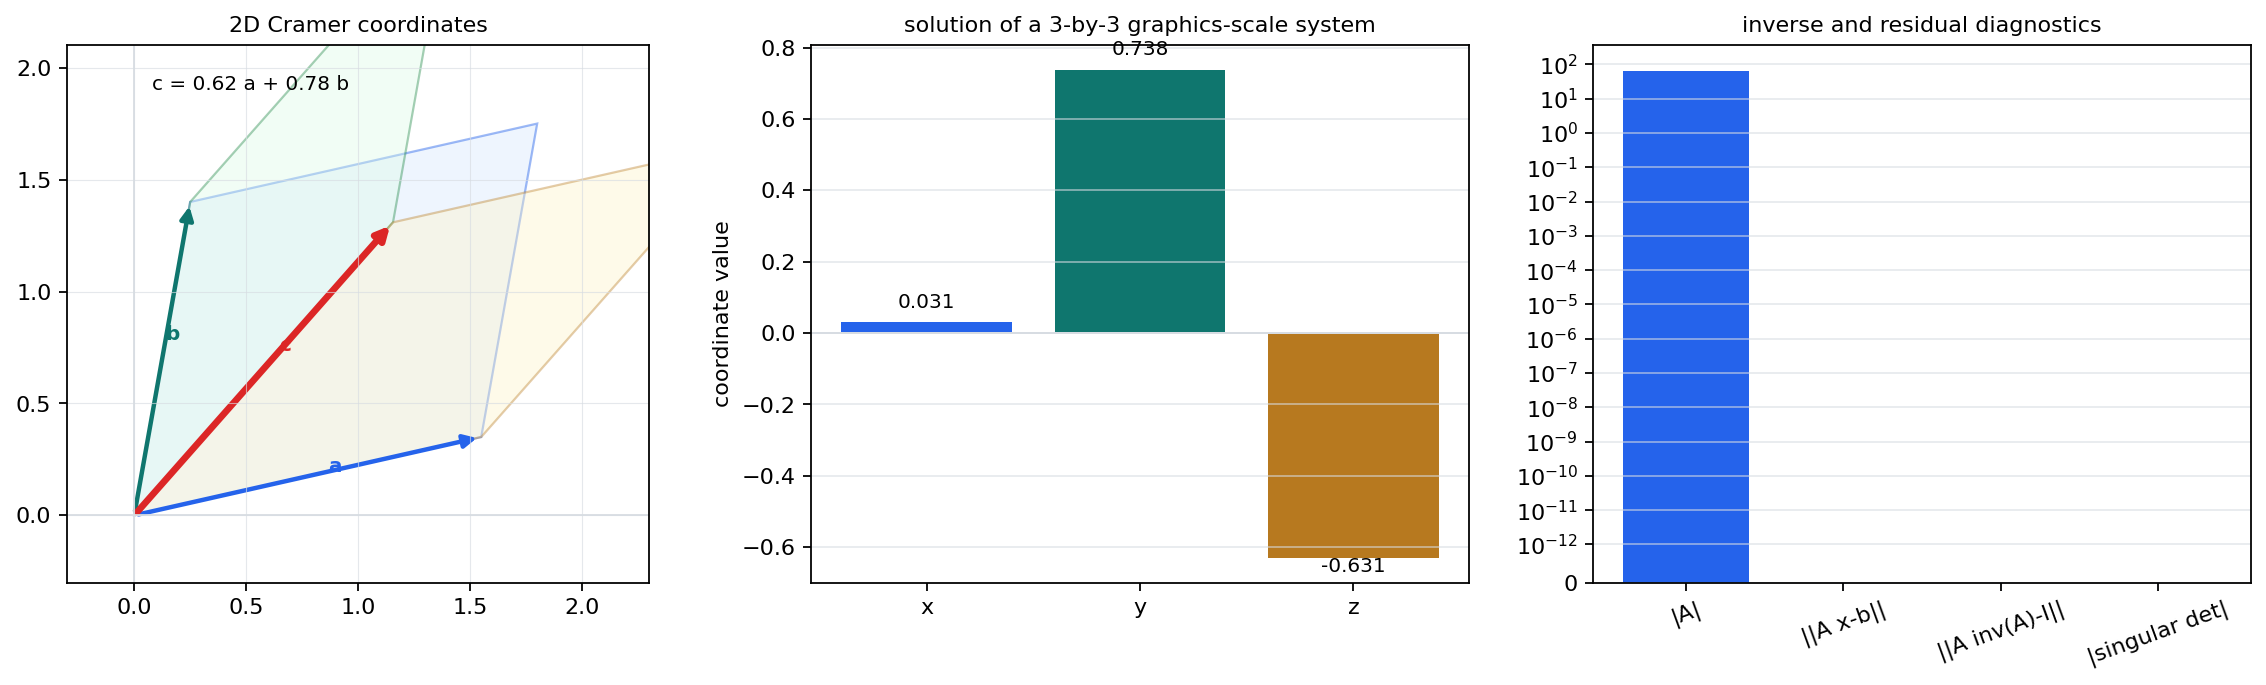

{'cramer_2d_alpha': 0.6199999999999999,
 'cramer_2d_beta': 0.78,
 'cramer_2d_error': 1.1102230246251565e-16,
 'det_A': -64.99999999999999,
 'solve_residual_norm': 8.95090418262362e-16,
 'cramer_solution_error': 3.3422138886441676e-16,
 'inverse_identity_error': 1.6653345369377348e-16,
 'singular_example_det': 0.0}

In [6]:
basis_a = np.array([1.55, .35]); basis_b = np.array([.25, 1.4]); coefficients = np.array([.62, .78])
target_c = coefficients[0] * basis_a + coefficients[1] * basis_b
cramer_den = float(np.linalg.det(np.column_stack([basis_a, basis_b])))
cramer_alpha = float(np.linalg.det(np.column_stack([target_c, basis_b])) / cramer_den)
cramer_beta = float(np.linalg.det(np.column_stack([basis_a, target_c])) / cramer_den)
system_A = np.array([[3.0,7.0,2.0], [2.0,-4.0,-3.0], [5.0,2.0,1.0]]); system_b = np.array([4.0,-1.0,1.0])
solution = np.linalg.solve(system_A, system_b); det_A = float(np.linalg.det(system_A)); cramer_solution = []
for col in range(3):
    replaced = system_A.copy(); replaced[:, col] = system_b; cramer_solution.append(float(np.linalg.det(replaced) / det_A))
cramer_solution = np.array(cramer_solution); residual = system_A @ solution - system_b
inverse_identity_error = max_abs(system_A @ np.linalg.inv(system_A) - np.eye(3)); singular_example = np.array([[1.0,2.0,3.0], [2.0,4.0,6.0], [0.0,1.0,1.0]])
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
setup_2d(axes[0], "2D Cramer coordinates", xlim=(-.3,2.3), ylim=(-.3,2.1))
axes[0].add_patch(Polygon(np.array([[0,0], basis_a, basis_a + basis_b, basis_b]), closed=True, facecolor="#dbeafe", edgecolor=PALETTE["blue"], alpha=.45))
axes[0].add_patch(Polygon(np.array([[0,0], target_c, target_c + basis_b, basis_b]), closed=True, facecolor="#dcfce7", edgecolor=PALETTE["green"], alpha=.38))
axes[0].add_patch(Polygon(np.array([[0,0], basis_a, basis_a + target_c, target_c]), closed=True, facecolor="#fef3c7", edgecolor=PALETTE["gold"], alpha=.38))
arrow2(axes[0], [0,0], basis_a, PALETTE["blue"], "a"); arrow2(axes[0], [0,0], basis_b, PALETTE["teal"], "b"); arrow2(axes[0], [0,0], target_c, PALETTE["red"], "c", linewidth=3.0)
axes[0].text(.08, 1.9, f"c = {cramer_alpha:.2f} a + {cramer_beta:.2f} b", fontsize=9)
axes[1].bar(["x", "y", "z"], solution, color=[PALETTE["blue"], PALETTE["teal"], PALETTE["gold"]]); axes[1].axhline(0, color=PALETTE["grid"], linewidth=.9)
axes[1].set_title("solution of a 3-by-3 graphics-scale system", fontsize=10); axes[1].set_ylabel("coordinate value"); axes[1].grid(axis="y", color=PALETTE["grid"], alpha=.6)
for i, value in enumerate(solution): axes[1].text(i, value + .04 * np.sign(value if value else 1), f"{value:.3f}", ha="center", fontsize=9)
axes[2].bar(["|A|", "||A x-b||", "||A inv(A)-I||", "|singular det|"], [abs(det_A), np.linalg.norm(residual), inverse_identity_error, abs(np.linalg.det(singular_example))], color=[PALETTE["blue"], PALETTE["teal"], PALETTE["gold"], PALETTE["red"]])
axes[2].set_yscale("symlog", linthresh=1e-12); axes[2].set_title("inverse and residual diagnostics", fontsize=10); axes[2].tick_params(axis="x", rotation=20); axes[2].grid(axis="y", color=PALETTE["grid"], alpha=.6)
fig.tight_layout(); inverse_path = remember(save_matplotlib(fig, UNIT, "inverse-linear-system-cramer.png"), "image"); close(fig)
rows = [{"unknown": name, "solve_value": value, "cramer_value": cvalue, "absolute_difference": abs(value-cvalue)} for name, value, cvalue in zip(["x","y","z"], solution, cramer_solution)]
solution_table_path = remember(save_table_csv(rows, UNIT, "linear-system-solution-checks.csv"), "table")
inverse_checks = {"cramer_2d_alpha": cramer_alpha, "cramer_2d_beta": cramer_beta, "cramer_2d_error": float(np.linalg.norm(np.array([cramer_alpha, cramer_beta]) - coefficients)), "det_A": det_A, "solve_residual_norm": float(np.linalg.norm(residual)), "cramer_solution_error": float(np.linalg.norm(solution - cramer_solution)), "inverse_identity_error": inverse_identity_error, "singular_example_det": float(np.linalg.det(singular_example))}
assert inverse_checks["cramer_2d_error"] < 1e-12 and inverse_checks["solve_residual_norm"] < 1e-12
assert inverse_checks["cramer_solution_error"] < 1e-10 and inverse_identity_error < 1e-12 and abs(inverse_checks["singular_example_det"]) < 1e-12
numeric_checks["inverse_and_systems"] = inverse_checks
display_artifact(inverse_path, width=980); display_artifact(solution_table_path); inverse_checks

## Eigenvectors and Symmetric Diagonalization

An eigenvector is a direction that a matrix does not turn. The matrix may stretch it, shrink it, or reverse it, but the vector stays on the same line. For arbitrary real matrices, eigenvalues can be complex and eigenvectors can be poorly behaved. The cleanest graphics geometry is the symmetric case: real symmetric matrices have real eigenvalues and an orthonormal eigenbasis.

Diagonalization writes a symmetric matrix as `A = Q D Q.T`. Read right to left: rotate or reflect coordinates into the eigenbasis, scale along the eigen-directions, then rotate back. The diagonal matrix is the shape of the transformation once the coordinate axes are chosen correctly.

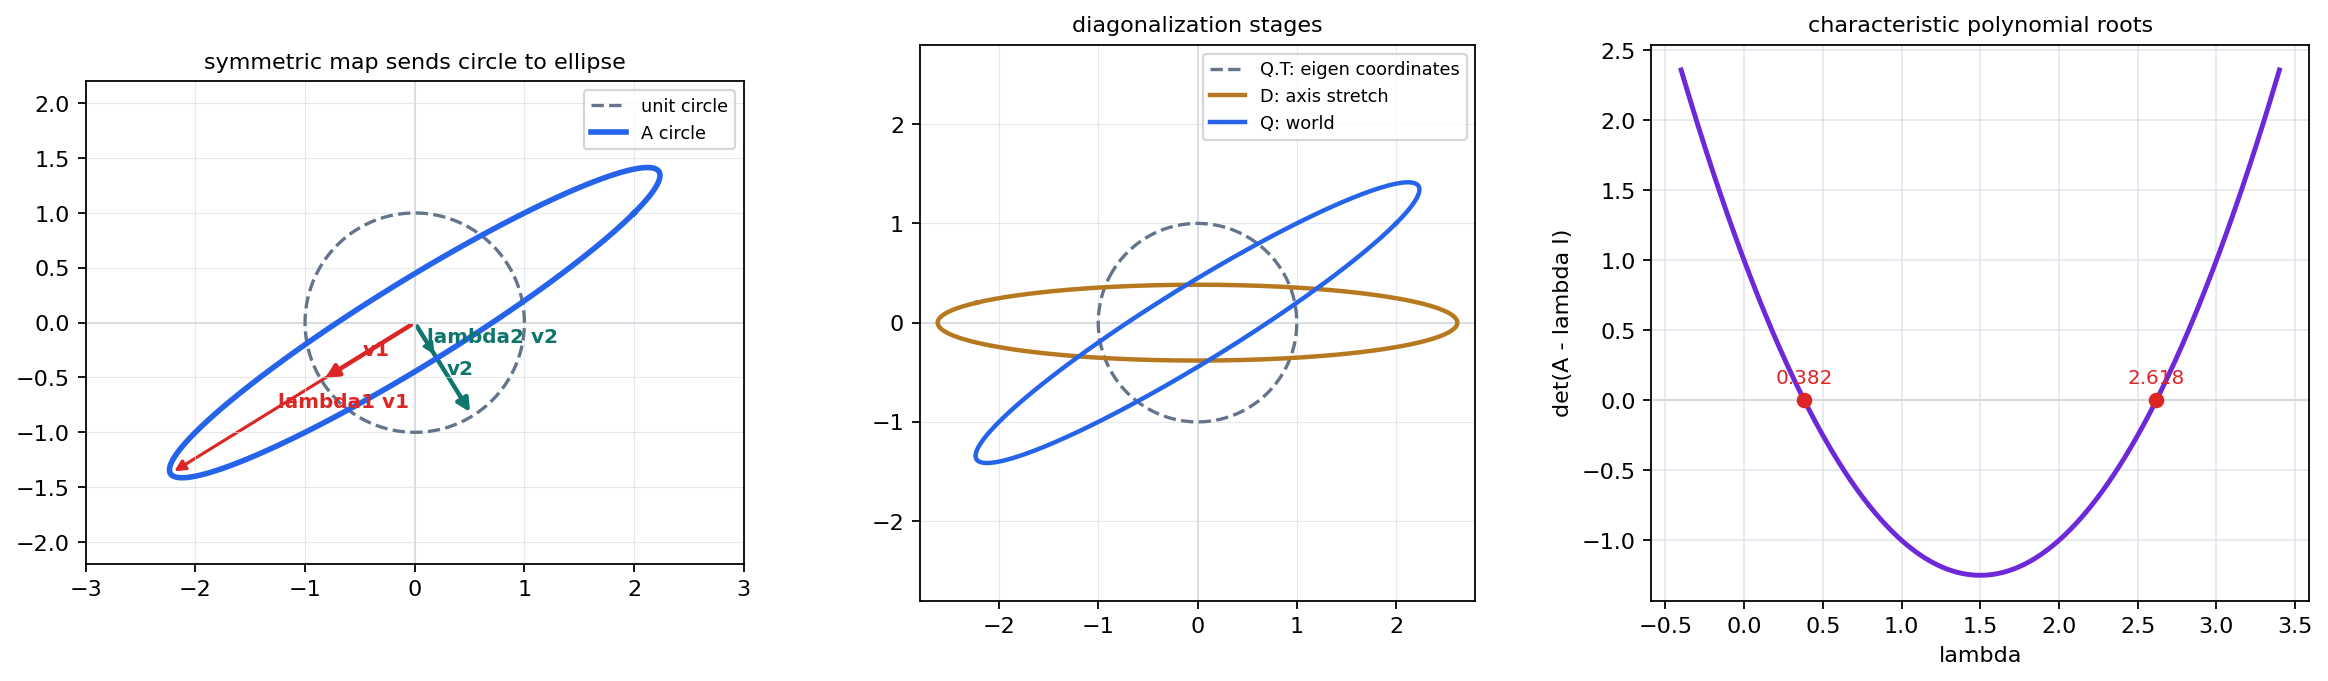

{'eigenvalues': [2.618033988749895, 0.38196601125010515],
 'char_poly_det_A_minus_lambda_I': 'lambda**2 - 3*lambda + 1',
 'eigen_residual': 2.220446049250313e-16,
 'orthogonality_error': 2.220446049250313e-16,
 'reconstruction_error': 4.440892098500626e-16,
 'trace_root_error': 0.0,
 'det_root_error': 0.0,
 'symbolic_trace_error': '0',
 'symbolic_det_error': '0'}

In [7]:
eig_A = np.array([[2.0, 1.0], [1.0, 1.0]])
eig_values, eig_vectors = np.linalg.eigh(eig_A); order = np.argsort(eig_values)[::-1]
eig_values = eig_values[order]; Q = eig_vectors[:, order]; D = np.diag(eig_values)
circle = circle_points(300); ellipse = circle @ eig_A.T
lam = sp.symbols("lambda"); sym_A = sp.Matrix([[2, 1], [1, 1]])
char_poly = sp.expand((sym_A - lam * sp.eye(2)).det()); poly_fn = sp.lambdify(lam, char_poly, "numpy")
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
setup_2d(axes[0], "symmetric map sends circle to ellipse", xlim=(-3,3), ylim=(-2.2,2.2))
axes[0].plot(circle[:,0], circle[:,1], color=PALETTE["gray"], linestyle="--", label="unit circle")
axes[0].plot(ellipse[:,0], ellipse[:,1], color=PALETTE["blue"], linewidth=2.5, label="A circle")
for idx, (value, vec, color) in enumerate(zip(eig_values, Q.T, [PALETTE["red"], PALETTE["teal"]]), start=1):
    arrow2(axes[0], [0,0], vec, color, f"v{idx}"); arrow2(axes[0], [0,0], eig_A @ vec, color, f"lambda{idx} v{idx}", linewidth=1.4, mutation_scale=10)
axes[0].legend(loc="upper right", fontsize=8)
setup_2d(axes[1], "diagonalization stages", xlim=(-2.8,2.8), ylim=(-2.8,2.8))
stage_qt = circle @ Q; stage_d = stage_qt @ D; stage_back = stage_d @ Q.T
axes[1].plot(stage_qt[:,0], stage_qt[:,1], color=PALETTE["gray"], linestyle="--", label="Q.T: eigen coordinates")
axes[1].plot(stage_d[:,0], stage_d[:,1], color=PALETTE["gold"], linewidth=2, label="D: axis stretch")
axes[1].plot(stage_back[:,0], stage_back[:,1], color=PALETTE["blue"], linewidth=2, label="Q: world")
axes[1].legend(loc="upper right", fontsize=8)
xs = np.linspace(-.4, 3.4, 400); axes[2].plot(xs, poly_fn(xs), color=PALETTE["violet"], linewidth=2.2); axes[2].axhline(0, color=PALETTE["grid"], linewidth=1)
axes[2].scatter(eig_values, [0,0], color=PALETTE["red"], zorder=3)
for value in eig_values: axes[2].text(value, .12, f"{value:.3f}", ha="center", fontsize=9, color=PALETTE["red"])
axes[2].set_title("characteristic polynomial roots", fontsize=10); axes[2].set_xlabel("lambda"); axes[2].set_ylabel("det(A - lambda I)"); axes[2].grid(True, color=PALETTE["grid"], alpha=.65)
fig.tight_layout(); eigen_path = remember(save_matplotlib(fig, UNIT, "eigen-diagonalization-geometry.png"), "image"); close(fig)
eigen_residual = max_abs(eig_A @ Q - Q @ D); orthogonality_error = max_abs(Q.T @ Q - np.eye(2)); reconstruction_error = max_abs(eig_A - Q @ D @ Q.T)
trace_root_error = abs(float(np.trace(eig_A) - eig_values.sum())); det_root_error = abs(float(np.linalg.det(eig_A) - np.prod(eig_values)))
exact_roots = sp.solve(sp.Eq(char_poly, 0), lam); symbolic_trace_error = sp.simplify(sum(exact_roots) - sp.trace(sym_A)); symbolic_det_error = sp.simplify(sp.prod(exact_roots) - sym_A.det())
eigen_checks = {"eigenvalues": [float(v) for v in eig_values], "char_poly_det_A_minus_lambda_I": str(char_poly), "eigen_residual": eigen_residual, "orthogonality_error": orthogonality_error, "reconstruction_error": reconstruction_error, "trace_root_error": trace_root_error, "det_root_error": det_root_error, "symbolic_trace_error": str(symbolic_trace_error), "symbolic_det_error": str(symbolic_det_error)}
assert eigen_residual < 1e-12 and orthogonality_error < 1e-12 and reconstruction_error < 1e-12
assert trace_root_error < 1e-12 and det_root_error < 1e-12 and eigen_checks["symbolic_trace_error"] == "0" and eigen_checks["symbolic_det_error"] == "0"
numeric_checks["eigen_diagonalization"] = eigen_checks
display_artifact(eigen_path, width=980); eigen_checks

## SVD and Eigen Geometry

The SVD is the practical geometry for a general real matrix. A nonsymmetric transform can shear a circle into an ellipse without giving a clean orthogonal eigenvector story. Singular vectors avoid that problem. They find orthonormal input directions, scale them by nonnegative singular values, and rotate or reflect the result into output directions.

For a square 2D matrix, the product of the singular values equals the absolute determinant, so the SVD still knows the area scale. The symmetric matrices `A.T @ A` and `A @ A.T` have eigenvalues equal to the squared singular values. This is the bridge from the symmetric eigen story to general graphics transforms.

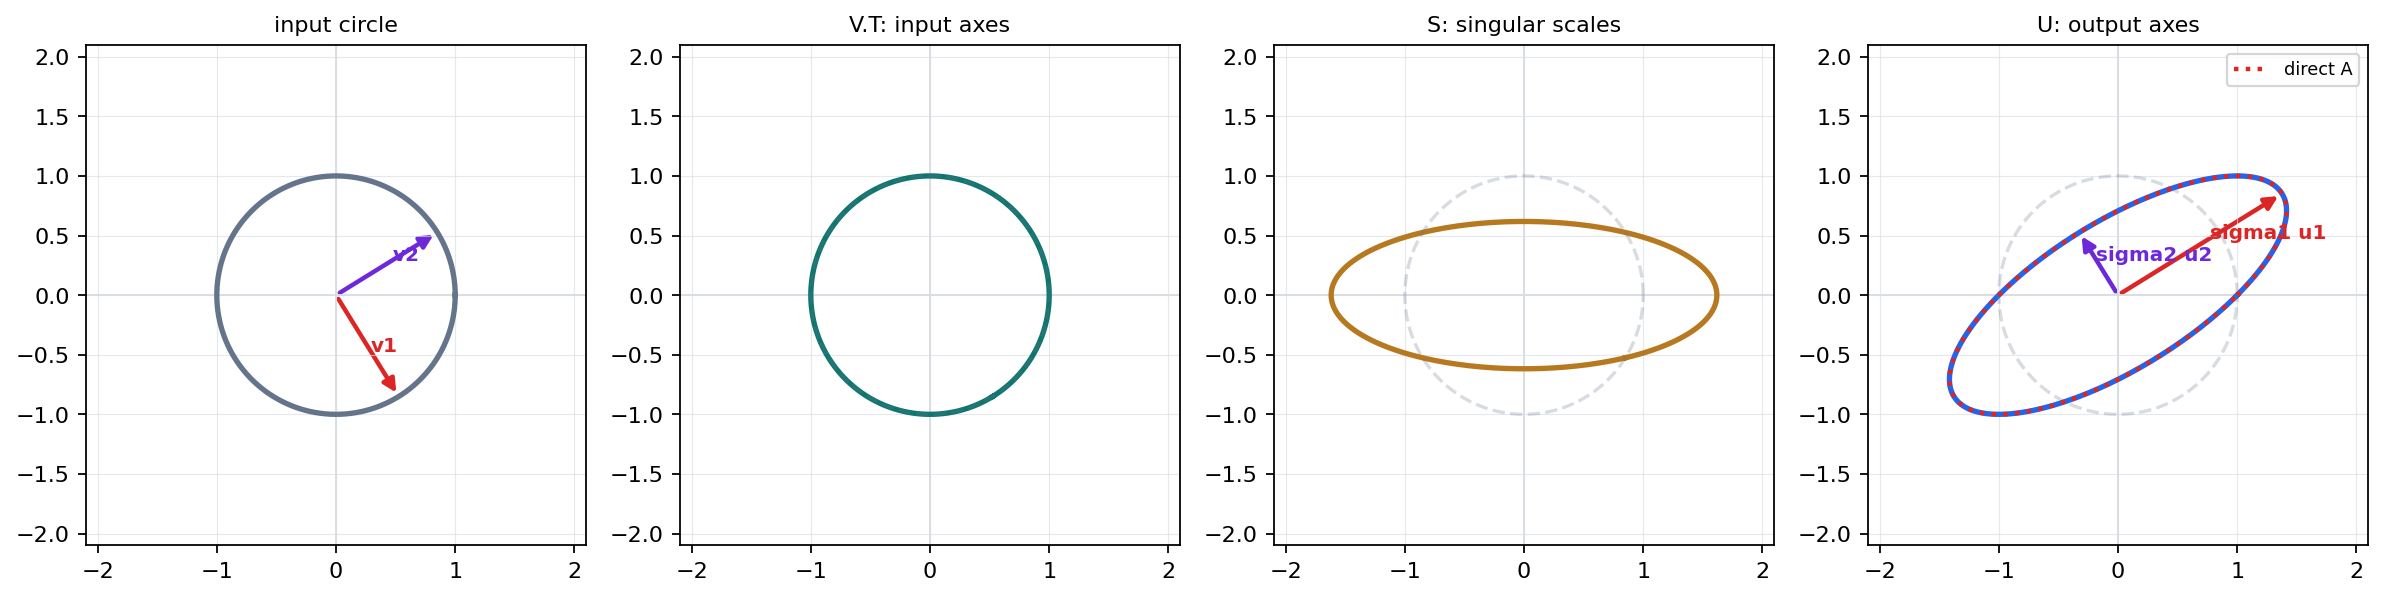

{'singular_values': [1.618033988749895, 0.6180339887498948],
 'svd_reconstruction_error': 2.220446049250313e-16,
 'direct_stage_error': 2.482534153247273e-16,
 'sigma_squared_vs_eig_ata_error': 5.551115123125783e-17,
 'sigma_squared_vs_eig_aat_error': 5.551115123125783e-17,
 'area_scale_error': 1.1102230246251565e-16,
 'condition_number': 2.6180339887498953}

In [8]:
svd_A = np.array([[1.0, 1.0], [0.0, 1.0]])
U, singular_values, Vt = np.linalg.svd(svd_A); S = np.diag(singular_values)
svd_circle = circle_points(300); stage0 = svd_circle; stage1 = stage0 @ Vt.T; stage2 = stage1 @ S.T; stage3 = stage2 @ U.T; direct = stage0 @ svd_A.T
fig, axes = plt.subplots(1, 4, figsize=(15, 4.1))
for ax, (pts, title, color) in zip(axes, [(stage0,"input circle",PALETTE["gray"]), (stage1,"V.T: input axes",PALETTE["teal"]), (stage2,"S: singular scales",PALETTE["gold"]), (stage3,"U: output axes",PALETTE["blue"])]):
    setup_2d(ax, title, xlim=(-2.1,2.1), ylim=(-2.1,2.1)); ax.plot(pts[:,0], pts[:,1], color=color, linewidth=2.4); ax.plot(stage0[:,0], stage0[:,1], color=PALETTE["gray"], alpha=.25, linestyle="--")
axes[-1].plot(direct[:,0], direct[:,1], color=PALETTE["red"], linestyle=":", linewidth=2, label="direct A"); axes[-1].legend(loc="upper right", fontsize=8)
for idx, vec in enumerate(Vt.T): arrow2(axes[0], [0,0], vec, [PALETTE["red"], PALETTE["violet"]][idx], f"v{idx+1}")
for idx, vec in enumerate(U.T): arrow2(axes[-1], [0,0], singular_values[idx] * vec, [PALETTE["red"], PALETTE["violet"]][idx], f"sigma{idx+1} u{idx+1}")
fig.tight_layout(); svd_path = remember(save_matplotlib(fig, UNIT, "determinant-svd-geometry.png"), "image"); close(fig)
svd_reconstruction_error = max_abs(svd_A - U @ S @ Vt); direct_stage_error = float(np.max(np.linalg.norm(stage3 - direct, axis=1)))
sigma_squared = np.sort(singular_values**2)[::-1]; eig_ata = np.sort(np.linalg.eigvalsh(svd_A.T @ svd_A))[::-1]; eig_aat = np.sort(np.linalg.eigvalsh(svd_A @ svd_A.T))[::-1]
area_scale_error = abs(float(abs(np.linalg.det(svd_A)) - np.prod(singular_values))); condition_number = float(singular_values.max() / singular_values.min())
svd_checks = {"singular_values": [float(v) for v in singular_values], "svd_reconstruction_error": svd_reconstruction_error, "direct_stage_error": direct_stage_error, "sigma_squared_vs_eig_ata_error": float(np.linalg.norm(sigma_squared - eig_ata)), "sigma_squared_vs_eig_aat_error": float(np.linalg.norm(sigma_squared - eig_aat)), "area_scale_error": area_scale_error, "condition_number": condition_number}
assert svd_reconstruction_error < 1e-12 and direct_stage_error < 1e-12
assert svd_checks["sigma_squared_vs_eig_ata_error"] < 1e-12 and svd_checks["sigma_squared_vs_eig_aat_error"] < 1e-12 and area_scale_error < 1e-12
numeric_checks["svd_geometry"] = svd_checks
display_artifact(svd_path, width=1040); svd_checks

## Applied Lab: Normal Vectors Are Not Ordinary Vectors

Graphics code often stores positions, tangent vectors, and normals side by side, but a normal is not used the same way as a tangent. A tangent vector says how to move along a surface. A normal says which directions are perpendicular to that surface. When a linear map contains nonuniform scale or shear, applying the same matrix to both tangents and normals breaks the perpendicularity constraint.

The correct normal transform for an invertible linear map `A` is `inv(A).T`. The lab below transforms a small tangent patch and compares two candidate normals: the inverse-transpose normal and the naive `A @ n` normal. The check is geometric: the correct normal must be perpendicular to both transformed tangents.

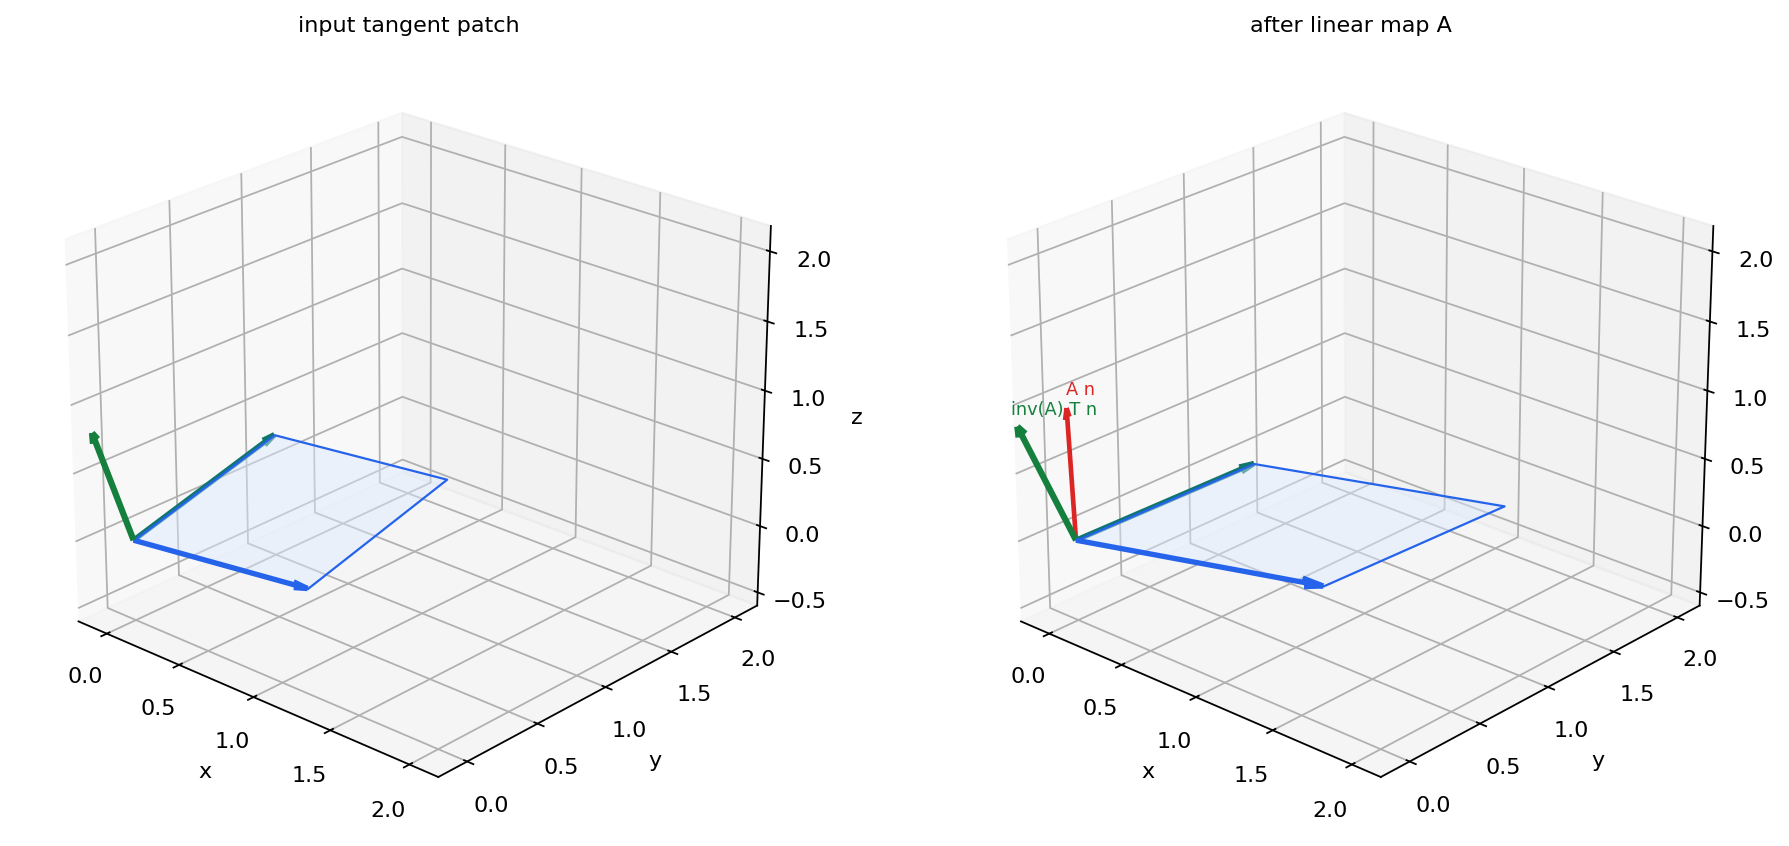

{'det_A3': 1.2191100000000004,
 'correct_dot_transformed_u': 0.0,
 'correct_dot_transformed_v': 5.551115123125783e-17,
 'naive_dot_transformed_u': 0.17795824299969276,
 'naive_dot_transformed_v': 0.2694007653288,
 'correct_normal_alignment_with_cross_product': 0.9999999999999999}

In [9]:
A3 = np.array([[1.35, .35, .05], [.10, .82, .20], [.18, -.05, 1.12]])
tangent_u = np.array([1.0, .18, 0.0]); tangent_v = np.array([0.0, 1.0, .32]); normal = normalize(np.cross(tangent_u, tangent_v))
transformed_u = A3 @ tangent_u; transformed_v = A3 @ tangent_v; geometric_normal = normalize(np.cross(transformed_u, transformed_v))
correct_normal = normalize(np.linalg.inv(A3).T @ normal); naive_normal = normalize(A3 @ normal)
if np.dot(geometric_normal, correct_normal) < 0: geometric_normal = -geometric_normal
if np.dot(geometric_normal, naive_normal) < 0: naive_normal = -naive_normal
patch = np.array([[0,0,0], tangent_u, tangent_u + tangent_v, tangent_v]); transformed_patch = patch @ A3.T
fig = plt.figure(figsize=(12, 5.4)); ax1 = fig.add_subplot(1,2,1, projection="3d"); ax2 = fig.add_subplot(1,2,2, projection="3d")
for ax, pts, tu, tv, nvec, title in [(ax1, patch, tangent_u, tangent_v, normal, "input tangent patch"), (ax2, transformed_patch, transformed_u, transformed_v, correct_normal, "after linear map A")]:
    ax.add_collection3d(Poly3DCollection([[pts[0], pts[1], pts[2], pts[3]]], facecolor="#dbeafe", edgecolor=PALETTE["blue"], linewidth=1, alpha=.45))
    ax.quiver(0,0,0, *tu, color=PALETTE["blue"], linewidth=2.4, arrow_length_ratio=.08); ax.quiver(0,0,0, *tv, color=PALETTE["teal"], linewidth=2.4, arrow_length_ratio=.08); ax.quiver(0,0,0, *nvec, color=PALETTE["green"], linewidth=2.8, arrow_length_ratio=.08)
    ax.set_title(title, fontsize=10); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z"); ax.set_box_aspect((1,1,.85)); ax.view_init(elev=24, azim=-48)
ax2.quiver(0,0,0, *naive_normal, color=PALETTE["red"], linewidth=2.1, arrow_length_ratio=.08)
ax2.text(*(correct_normal * 1.1), "inv(A).T n", color=PALETTE["green"], fontsize=8); ax2.text(*(naive_normal * 1.1), "A n", color=PALETTE["red"], fontsize=8)
limit = float(np.max(np.abs(np.vstack([patch, transformed_patch])))) + .4
for ax in [ax1, ax2]: ax.set_xlim(-.2, limit); ax.set_ylim(-.2, limit); ax.set_zlim(-.6, limit)
fig.tight_layout(); normal_lab_path = remember(save_matplotlib(fig, UNIT, "graphics-normal-transform-lab.png"), "image"); close(fig)
correct_dot_u = float(abs(np.dot(correct_normal, transformed_u))); correct_dot_v = float(abs(np.dot(correct_normal, transformed_v)))
naive_dot_u = float(abs(np.dot(naive_normal, transformed_u))); naive_dot_v = float(abs(np.dot(naive_normal, transformed_v))); normal_alignment = float(abs(np.dot(correct_normal, geometric_normal)))
normal_checks = {"det_A3": float(np.linalg.det(A3)), "correct_dot_transformed_u": correct_dot_u, "correct_dot_transformed_v": correct_dot_v, "naive_dot_transformed_u": naive_dot_u, "naive_dot_transformed_v": naive_dot_v, "correct_normal_alignment_with_cross_product": normal_alignment}
assert abs(normal_checks["det_A3"]) > 1e-9 and correct_dot_u < 1e-12 and correct_dot_v < 1e-12
assert normal_alignment > 1.0 - 1e-12 and max(naive_dot_u, naive_dot_v) > 1e-2
numeric_checks["graphics_normal_transform_lab"] = normal_checks
display_artifact(normal_lab_path, width=900); normal_checks

## Sanity checks

The final cell checks mathematical identities, artifact integrity, image nonblankness, and the numeric facts claimed by the visuals. The checks are deliberately redundant: determinant area, inverse residual, eigen reconstruction, SVD reconstruction, and inverse-transpose normal perpendicularity each catch a different class of graphics implementation error.

The notebook contains the required Translation guide, Visual storyboard, Applied lab, Sanity checks, and Takeaways as chapter-local teaching material. The generated JSON files are book-local evidence that a QC worker can rerun without reading hidden state.

In [10]:
numeric_summary = {"chapter": CHAPTER, "title": TITLE, "source_span": SOURCE_SPAN, "storyboard_item_count": len(visual_storyboard), "checks": numeric_checks, "artifacts": {"images": [rel_book(p) for p in image_paths], "html": [rel_book(p) for p in html_paths], "tables": [rel_book(p) for p in table_paths]}}
numeric_path = remember(save_json(numeric_summary, UNIT, "linear-algebra-invariants.json"), "check")
numeric_alias_path = remember(save_json(numeric_summary, UNIT, "numeric-checks.json"), "check")
all_required = [*image_paths, *html_paths, *table_paths, *check_paths]
artifact_records = assert_artifacts(all_required)
image_records = [assert_nonblank_image(path) for path in image_paths]
assert numeric_checks["determinants"]["shear_area_error"] < 1e-12
assert numeric_checks["determinants"]["triple_product_error"] < 1e-12
assert numeric_checks["matrices"]["det_product_error"] < 1e-12
assert numeric_checks["inverse_and_systems"]["solve_residual_norm"] < 1e-12
assert numeric_checks["inverse_and_systems"]["cramer_solution_error"] < 1e-10
assert numeric_checks["eigen_diagonalization"]["reconstruction_error"] < 1e-12
assert numeric_checks["svd_geometry"]["svd_reconstruction_error"] < 1e-12
assert numeric_checks["graphics_normal_transform_lab"]["correct_dot_transformed_u"] < 1e-12
assert numeric_checks["graphics_normal_transform_lab"]["correct_dot_transformed_v"] < 1e-12
final_report = {"chapter": CHAPTER, "title": TITLE, "printed_pages": PRINTED_PAGES, "pdf_pages": PDF_PAGES, "artifact_count_before_final": len(artifact_records), "image_count": len(image_records), "html_count": len(html_paths), "table_count": len(table_paths), "check_count_before_final": len(check_paths), "nonblank_images": [rel_book(record["path"]) for record in image_records], "max_image_stddev_minimum": min(record["max_channel_stddev"] for record in image_records), "invariant_json": rel_book(numeric_path), "numeric_checks_json": rel_book(numeric_alias_path), "core_identities_checked": ["determinant sign and shear invariance", "3D triple product equals determinant", "det(A @ B) equals det(A) det(B)", "transpose reverses product order", "inverse identity and Cramer residuals", "symmetric diagonalization reconstruction", "SVD reconstruction and sigma-squared eigen relation", "inverse-transpose normal perpendicularity"]}
final_path = remember(save_json(final_report, UNIT, "final-sanity.json"), "check")
assert_artifacts([final_path])
display_artifact(numeric_path); display_artifact(numeric_alias_path); display_artifact(final_path); final_report

{'chapter': 6,
 'title': 'Linear Algebra',
 'printed_pages': '107-126',
 'pdf_pages': '124-143',
 'artifact_count_before_final': 12,
 'image_count': 7,
 'html_count': 1,
 'table_count': 1,
 'check_count_before_final': 3,
 'nonblank_images': ['artifacts/chapter-06/figures/concept-dependency-map.png',
  'artifacts/chapter-06/figures/determinant-area-volume.png',
  'artifacts/chapter-06/figures/matrix-product-interpretations.png',
  'artifacts/chapter-06/figures/inverse-linear-system-cramer.png',
  'artifacts/chapter-06/figures/eigen-diagonalization-geometry.png',
  'artifacts/chapter-06/figures/determinant-svd-geometry.png',
  'artifacts/chapter-06/figures/graphics-normal-transform-lab.png'],
 'max_image_stddev_minimum': 27.412748962139997,
 'invariant_json': 'artifacts/chapter-06/checks/linear-algebra-invariants.json',
 'numeric_checks_json': 'artifacts/chapter-06/checks/numeric-checks.json',
 'core_identities_checked': ['determinant sign and shear invariance',
  '3D triple product equa

## Takeaways

- Determinants are signed area or volume measurements first and formulas second. That interpretation explains orientation, singularity, and determinant-based coordinate formulas.
- Matrix multiplication is engineered for composition. The row-column rule, the column-combination view, and transform order are the same operation seen from different angles.
- Inverses and Cramer's rule are most useful here as diagnostics for small systems: a near-zero determinant means the intended undo operation is fragile or impossible.
- Symmetric matrices have a clean eigenbasis: rotate to eigen-coordinates, scale by eigenvalues, rotate back.
- The SVD is the graphics-friendly extension for general real matrices: input singular directions, nonnegative stretches, output singular directions.
- Normals must be transformed as perpendicularity constraints using the inverse transpose, not as ordinary model-space vectors when the matrix includes nonuniform scale or shear.